 # Narrative Features Analysis — Monetary Relief Prediction
 **v1**: 14 selected features, time-based train/test split

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import QuantileTransformer

CSV_PATH      = "complaints-2026-05-19_22_40.csv"
NARRATIVE_COL = "Consumer complaint narrative"
TARGET_COL    = "Company response to consumer"
DATE_COL      = "Date received"

In [ ]:
df = pd.read_csv(CSV_PATH, on_bad_lines='skip', low_memory=False)
df["label"] = (df[TARGET_COL] == "Closed with monetary relief").astype(int)
df = df.dropna(subset=[NARRATIVE_COL]).reset_index(drop=True)
df["date"] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
narr = df[NARRATIVE_COL]

print(f"Rows: {len(df):,}  |  Positive rate: {df['label'].mean():.2%}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")

Rows: 177,339  |  Positive rate: 14.94%
Date range: 2017-04-24 → 2026-04-29


In [ ]:
def plot_dist(col, title, spearman_r, clip_pct=99):
    data0 = df.loc[df["label"] == 0, col].dropna()
    data1 = df.loc[df["label"] == 1, col].dropna()
    clip_val = df[col].quantile(clip_pct / 100)
    d0 = data0.clip(upper=clip_val)
    d1 = data1.clip(upper=clip_val)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"{title}   |   Spearman r = {spearman_r:+.4f}", fontsize=12, fontweight="bold")

    ax = axes[0]
    ax.hist(d0, bins=60, density=True, alpha=0.5, color="#2563eb", label=f"No relief  (median={d0.median():.2f})")
    ax.hist(d1, bins=60, density=True, alpha=0.5, color="#dc2626", label=f"Monetary relief  (median={d1.median():.2f})")
    ax.axvline(d0.median(), color="#2563eb", lw=1.5, linestyle="--")
    ax.axvline(d1.median(), color="#dc2626", lw=1.5, linestyle="--")
    ax.set_xlabel(col); ax.set_ylabel("Density")
    ax.set_title(f"Histogram (clipped at {clip_pct}th pct)")
    ax.legend(fontsize=8)

    ax = axes[1]
    ax.boxplot([d0, d1], labels=["No relief (0)", "Monetary relief (1)"],
               patch_artist=True,
               boxprops=dict(facecolor="#e0e7ff"),
               medianprops=dict(color="black", lw=2))
    ax.set_ylabel(col); ax.set_title("Boxplot by label")

    plt.tight_layout(); plt.show()

dollar_count  r=+0.1793  p=0.00e+00
# of '$XXX' mentions — specificity of financial claim


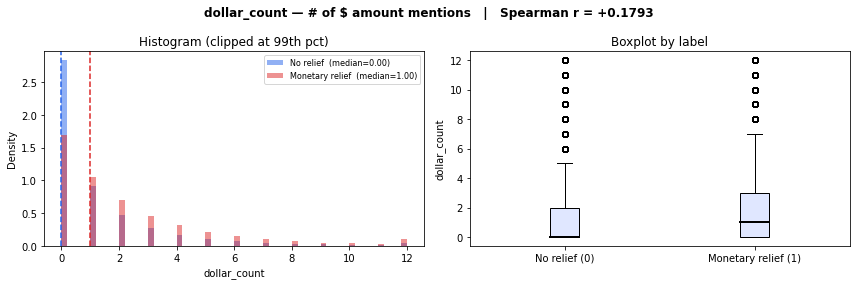

In [ ]:
df["dollar_count"] = narr.str.count(r'\$[\d,]+')
r, p = spearmanr(df["dollar_count"], df["label"])
print(f"dollar_count  r={r:+.4f}  p={p:.2e}")
print("# of '$XXX' mentions — specificity of financial claim")
plot_dist("dollar_count", "dollar_count — # of $ amount mentions", r)

sentence_count  r=+0.1196  p=0.00e+00
# of sentences — more sentences = more structured complaint


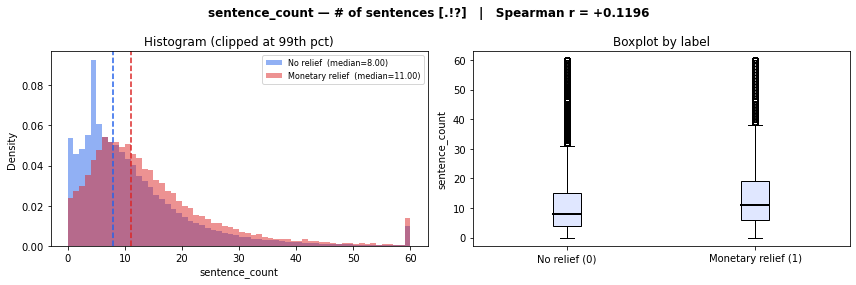

In [ ]:
df["sentence_count"] = narr.str.count(r'[.!?]+')
r, p = spearmanr(df["sentence_count"], df["label"])
print(f"sentence_count  r={r:+.4f}  p={p:.2e}")
print("# of sentences — more sentences = more structured complaint")
plot_dist("sentence_count", "sentence_count — # of sentences [.!?]", r)

lexical_diversity  r=-0.1040  p=0.00e+00
unique words ÷ total words — lower = more repetitive, focused language


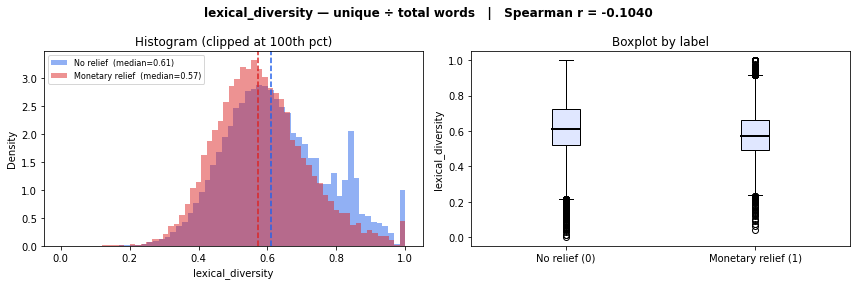

In [ ]:
df["lexical_diversity"] = narr.apply(
    lambda t: len(set(t.lower().split())) / len(t.split()) if t.split() else 0
)
r, p = spearmanr(df["lexical_diversity"], df["label"])
print(f"lexical_diversity  r={r:+.4f}  p={p:.2e}")
print("unique words ÷ total words — lower = more repetitive, focused language")
plot_dist("lexical_diversity", "lexical_diversity — unique ÷ total words", r, clip_pct=100)

word_count  r=+0.0964  p=0.00e+00
Total words — longer complaints get more relief


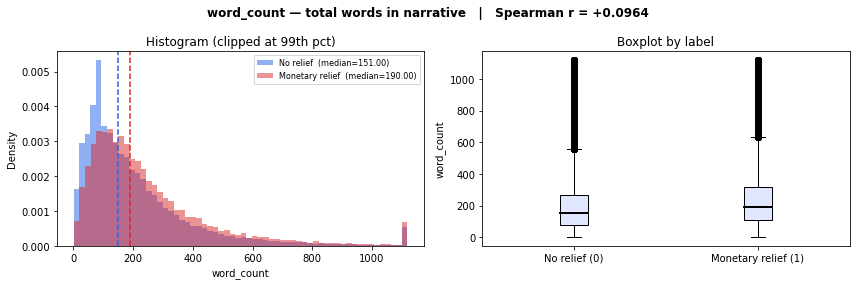

In [ ]:
df["word_count"] = narr.str.split().str.len()
r, p = spearmanr(df["word_count"], df["label"])
print(f"word_count  r={r:+.4f}  p={p:.2e}")
print("Total words — longer complaints get more relief")
plot_dist("word_count", "word_count — total words in narrative", r)

char_len  r=+0.0924  p=0.00e+00
Total characters — highly correlated with word_count


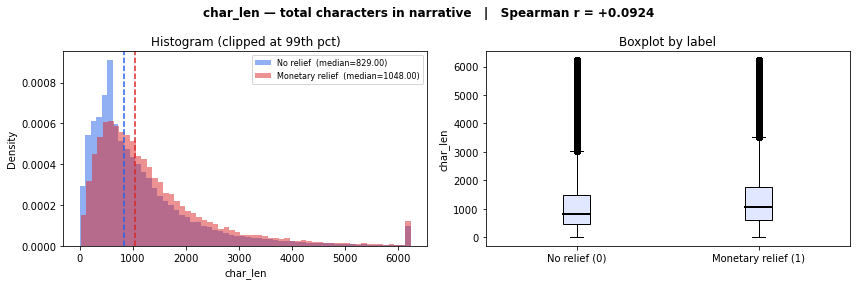

In [ ]:
df["char_len"] = narr.str.len()
r, p = spearmanr(df["char_len"], df["label"])
print(f"char_len  r={r:+.4f}  p={p:.2e}")
print("Total characters — highly correlated with word_count")
plot_dist("char_len", "char_len — total characters in narrative", r)

Computing Flesch-Kincaid... (~30s)
flesch_kincaid  r=+0.0827  p=9.25e-267
Readability score — higher = easier to read; simpler writing wins


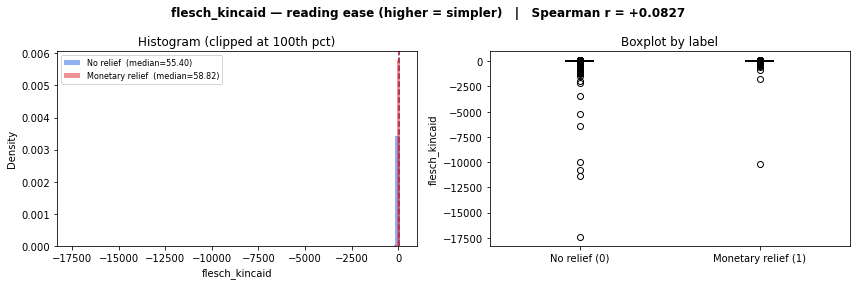

In [ ]:
def count_syllables(word):
    return max(1, len(re.findall(r'[aeiouy]+', word.lower().strip(".,!?;:'\""))))

def flesch_reading_ease(text):
    words = text.split()
    if not words:
        return np.nan
    sentences = max(1, len(re.findall(r'[.!?]+', text)))
    syllables  = sum(count_syllables(w) for w in words)
    return 206.835 - 1.015 * (len(words) / sentences) - 84.6 * (syllables / len(words))

print("Computing Flesch-Kincaid... (~30s)")
df["flesch_kincaid"] = narr.apply(flesch_reading_ease)
r, p = spearmanr(df["flesch_kincaid"], df["label"])
print(f"flesch_kincaid  r={r:+.4f}  p={p:.2e}")
print("Readability score — higher = easier to read; simpler writing wins")
plot_dist("flesch_kincaid", "flesch_kincaid — reading ease (higher = simpler)", r, clip_pct=100)

avg_sentence_len  r=-0.0587  p=2.23e-128
Words per sentence — shorter sentences = more direct writing


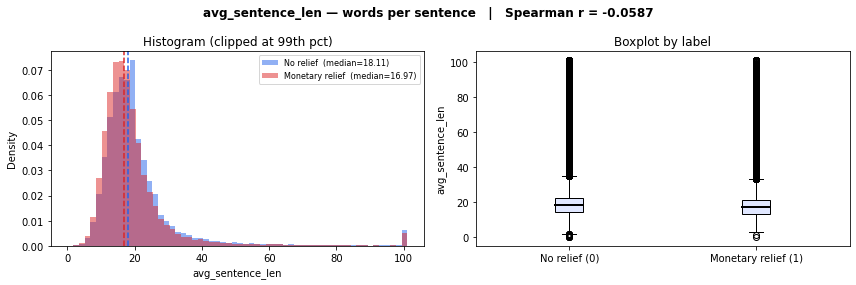

In [ ]:
df["avg_sentence_len"] = df["word_count"] / df["sentence_count"].replace(0, np.nan)
r, p = spearmanr(df["avg_sentence_len"].dropna(), df.loc[df["avg_sentence_len"].notna(), "label"])
print(f"avg_sentence_len  r={r:+.4f}  p={p:.2e}")
print("Words per sentence — shorter sentences = more direct writing")
plot_dist("avg_sentence_len", "avg_sentence_len — words per sentence", r)

date_count  r=+0.0546  p=3.17e-117
# of date mentions — more dates = better documented timeline


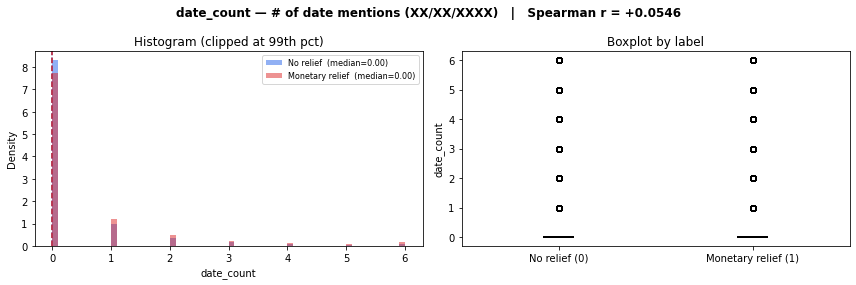

In [ ]:
df["date_count"] = narr.str.count(r'\b(?:XX|\d{1,2})/(?:XX|\d{1,2})/(?:XX|\d{2,4})\b')
r, p = spearmanr(df["date_count"], df["label"])
print(f"date_count  r={r:+.4f}  p={p:.2e}")
print("# of date mentions — more dates = better documented timeline")
plot_dist("date_count", "date_count — # of date mentions (XX/XX/XXXX)", r)

caps_ratio  r=+0.0436  p=2.54e-75
Proportion of CAPS words — emphasis / mild frustration signal


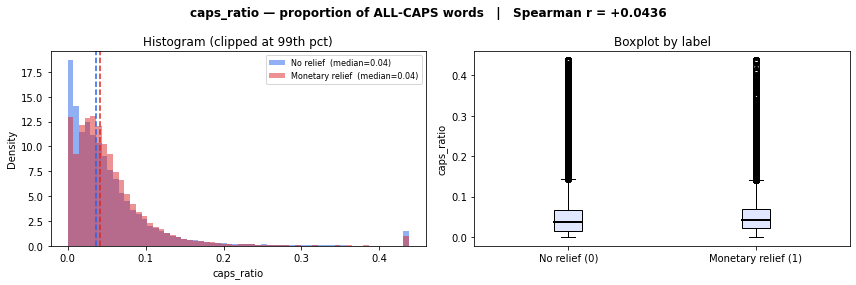

In [ ]:
df["caps_ratio"] = narr.apply(
    lambda t: sum(1 for w in t.split() if w.isupper() and len(w) > 1) / max(len(t.split()), 1)
)
r, p = spearmanr(df["caps_ratio"], df["label"])
print(f"caps_ratio  r={r:+.4f}  p={p:.2e}")
print("Proportion of CAPS words — emphasis / mild frustration signal")
plot_dist("caps_ratio", "caps_ratio — proportion of ALL-CAPS words", r)

avg_word_len  r=-0.0235  p=3.98e-23
Avg characters per word — shorter words = simpler vocabulary wins


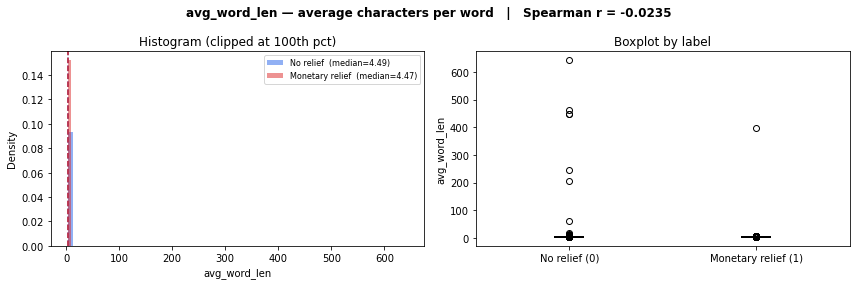

In [ ]:
df["avg_word_len"] = narr.apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0
)
r, p = spearmanr(df["avg_word_len"], df["label"])
print(f"avg_word_len  r={r:+.4f}  p={p:.2e}")
print("Avg characters per word — shorter words = simpler vocabulary wins")
plot_dist("avg_word_len", "avg_word_len — average characters per word", r, clip_pct=100)

exclamation_count  r=+0.0223  p=4.93e-21
# of '!' — emotional intensity; weakest narrative signal


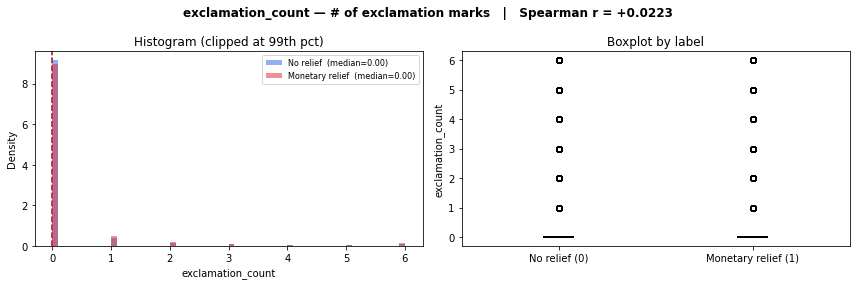

In [ ]:
df["exclamation_count"] = narr.str.count(r'!')
r, p = spearmanr(df["exclamation_count"], df["label"])
print(f"exclamation_count  r={r:+.4f}  p={p:.2e}")
print("# of '!' — emotional intensity; weakest narrative signal")
plot_dist("exclamation_count", "exclamation_count — # of exclamation marks", r)

total_dollar_amount  r=+0.1405  p=0.00e+00
Sum of all $ values — higher financial stakes = more relief


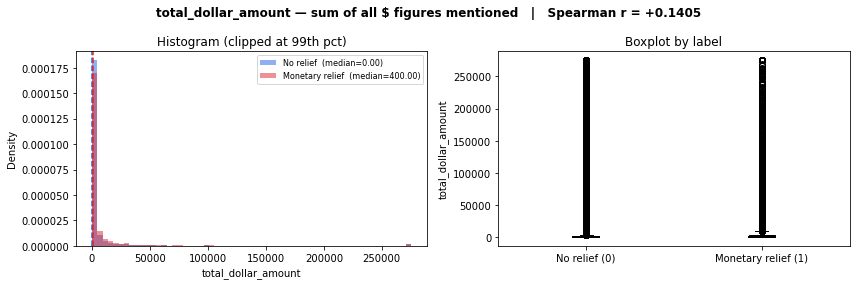

In [ ]:
def extract_dollar_amounts(text):
    amounts = []
    for m in re.findall(r'\$[\d,]+(?:\.\d+)?', text):
        try:
            amounts.append(float(m.replace('$', '').replace(',', '')))
        except ValueError:
            pass
    return amounts

dollar_series = narr.apply(extract_dollar_amounts)
df["total_dollar_amount"] = dollar_series.apply(lambda x: sum(x) if x else 0)
r, p = spearmanr(df["total_dollar_amount"], df["label"])
print(f"total_dollar_amount  r={r:+.4f}  p={p:.2e}")
print("Sum of all $ values — higher financial stakes = more relief")
plot_dist("total_dollar_amount", "total_dollar_amount — sum of all $ figures mentioned", r)

max_dollar_amount  r=+0.1354  p=0.00e+00
Largest single $ figure — one big claim more compelling than many small ones


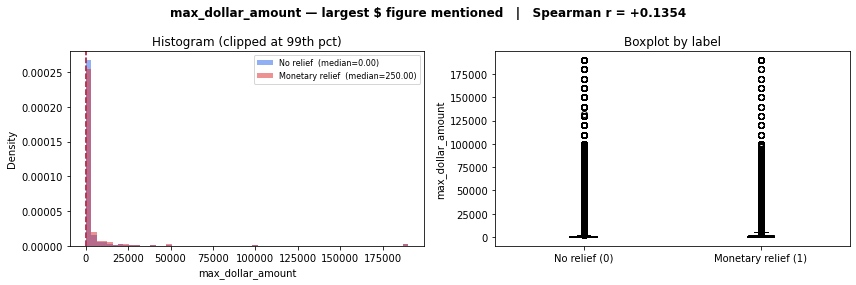

In [ ]:
df["max_dollar_amount"] = dollar_series.apply(lambda x: max(x) if x else 0)
r, p = spearmanr(df["max_dollar_amount"], df["label"])
print(f"max_dollar_amount  r={r:+.4f}  p={p:.2e}")
print("Largest single $ figure — one big claim more compelling than many small ones")
plot_dist("max_dollar_amount", "max_dollar_amount — largest $ figure mentioned", r)

paragraph_count  r=+0.0410  p=6.37e-67
# of paragraphs — organised, multi-paragraph complaint = prepared complainant


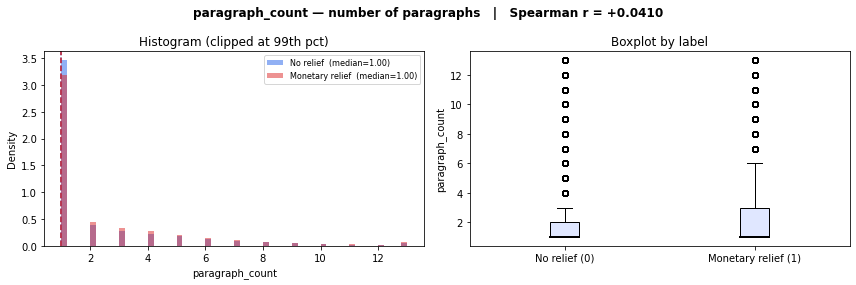

In [ ]:
df["paragraph_count"] = narr.str.count(r'\n\s*\n') + 1
r, p = spearmanr(df["paragraph_count"], df["label"])
print(f"paragraph_count  r={r:+.4f}  p={p:.2e}")
print("# of paragraphs — organised, multi-paragraph complaint = prepared complainant")
plot_dist("paragraph_count", "paragraph_count — number of paragraphs", r)

Train: 141,871 rows  (2017-04-24 → 2025-05-21)
Test:  35,468  rows  (2025-05-21 → 2026-04-29)
Cutoff date:         2025-05-21
Train positive rate: 15.51%
Test  positive rate: 12.65%


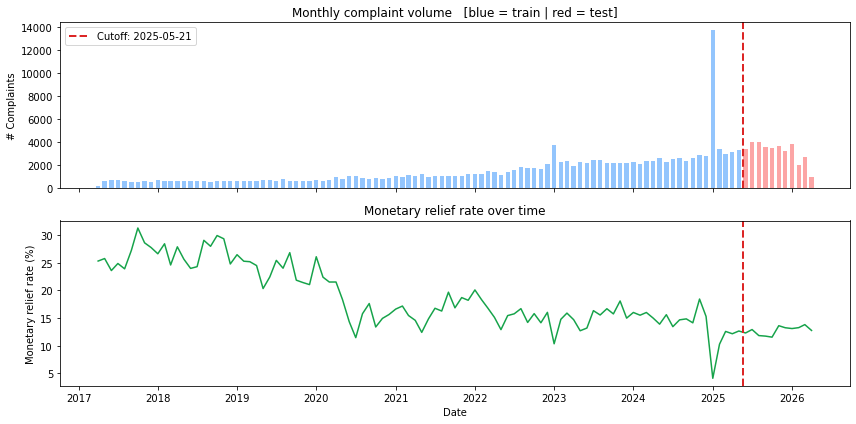

In [ ]:
FEATURES = [
    "dollar_count", "sentence_count", "lexical_diversity", "word_count",
    "char_len", "flesch_kincaid", "avg_sentence_len", "date_count",
    "caps_ratio", "avg_word_len", "exclamation_count",
    "total_dollar_amount", "max_dollar_amount", "paragraph_count",
]
df[FEATURES] = df[FEATURES].fillna(0)

split_idx   = int(len(df) * 0.80)
cutoff_date = df["date"].iloc[split_idx]
train_df    = df.iloc[:split_idx]
test_df     = df.iloc[split_idx:]

print(f"Train: {len(train_df):,} rows  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Test:  {len(test_df):,}  rows  ({test_df['date'].min().date()} → {test_df['date'].max().date()})")
print(f"Cutoff date:         {cutoff_date.date()}")
print(f"Train positive rate: {train_df['label'].mean():.2%}")
print(f"Test  positive rate: {test_df['label'].mean():.2%}")

# Plot: volume + positive rate over time
monthly = df.groupby(df["date"].dt.to_period("M")).agg(
    total=("label", "count"), positive=("label", "sum")
).reset_index()
monthly["date_ts"] = monthly["date"].dt.to_timestamp()
monthly["pos_rate"] = monthly["positive"] / monthly["total"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].bar(monthly["date_ts"], monthly["total"], width=20,
            color=["#93c5fd" if t < cutoff_date else "#fca5a5"
                   for t in monthly["date_ts"]])
axes[0].axvline(cutoff_date, color="#dc2626", lw=2, linestyle="--",
                label=f"Cutoff: {cutoff_date.date()}")
axes[0].set_ylabel("# Complaints")
axes[0].set_title("Monthly complaint volume   [blue = train | red = test]")
axes[0].legend()

axes[1].plot(monthly["date_ts"], monthly["pos_rate"] * 100, color="#16a34a", lw=1.5)
axes[1].axvline(cutoff_date, color="#dc2626", lw=2, linestyle="--")
axes[1].set_ylabel("Monetary relief rate (%)")
axes[1].set_title("Monetary relief rate over time")
axes[1].set_xlabel("Date")

plt.tight_layout(); plt.show()

In [ ]:
X_train = train_df[FEATURES].values
X_test  = test_df[FEATURES].values
y_train = train_df["label"].values
y_test  = test_df["label"].values

qt = QuantileTransformer(output_distribution="uniform", random_state=42)
X_train_sc = qt.fit_transform(X_train)
X_test_sc  = qt.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_sc, y_train)

prob_train = model.predict_proba(X_train_sc)[:, 1]
prob_test  = model.predict_proba(X_test_sc)[:, 1]

fpr_tr, tpr_tr, _ = roc_curve(y_train, prob_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  prob_test)
auc_tr = auc(fpr_tr, tpr_tr)
auc_te = auc(fpr_te, tpr_te)

print(f"In-sample  AUC: {auc_tr:.4f}")
print(f"Out-of-sample AUC: {auc_te:.4f}")
print(f"Gap: {auc_tr - auc_te:+.4f}")
print()
print(classification_report(y_test, model.predict(X_test_sc),
                             target_names=["No relief", "Monetary relief"]))

In-sample  AUC: 0.6654
Out-of-sample AUC: 0.6049
Gap: +0.0605

                 precision    recall  f1-score   support

      No relief       0.90      0.64      0.75     30982
Monetary relief       0.17      0.52      0.26      4486

       accuracy                           0.62     35468
      macro avg       0.54      0.58      0.50     35468
   weighted avg       0.81      0.62      0.69     35468



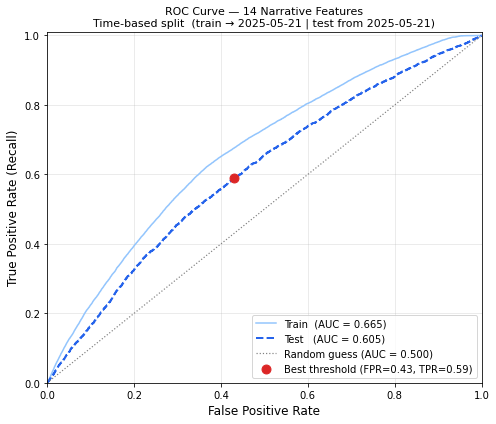

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr_tr, tpr_tr, color="#93c5fd", lw=1.5, linestyle="-",
        label=f"Train  (AUC = {auc_tr:.3f})")
ax.plot(fpr_te, tpr_te, color="#2563eb", lw=2.0, linestyle="--",
        label=f"Test   (AUC = {auc_te:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1.2, linestyle=":",
        label="Random guess (AUC = 0.500)")

best_idx = np.argmin(np.sqrt(fpr_te**2 + (1 - tpr_te)**2))
ax.scatter(fpr_te[best_idx], tpr_te[best_idx], s=80, zorder=5, color="#dc2626",
           label=f"Best threshold (FPR={fpr_te[best_idx]:.2f}, TPR={tpr_te[best_idx]:.2f})")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curve — 14 Narrative Features\n"
             f"Time-based split  (train → {train_df['date'].max().date()} | test from {test_df['date'].min().date()})",
             fontsize=11)
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

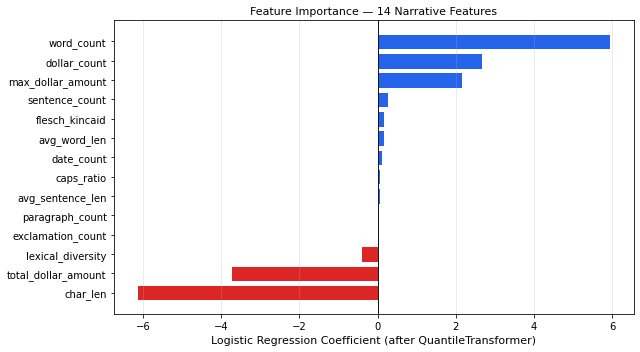

In [ ]:
coef_df = pd.DataFrame({
    "feature":     FEATURES,
    "coefficient": model.coef_[0],
}).sort_values("coefficient")

colors = ["#dc2626" if c < 0 else "#2563eb" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.9)
ax.set_xlabel("Logistic Regression Coefficient (after QuantileTransformer)", fontsize=11)
ax.set_title("Feature Importance — 14 Narrative Features", fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()